In [1]:
# Google Play Store App Success Prediction

import pandas as pd

# Load the dataset
df = pd.read_csv('googleplaystore.csv')

# Show basic info
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [2]:
# Step 2: Data Cleaning & Preprocessing

# Remove rows where all values are NaN
df.dropna(how='all', inplace=True)

# Drop clearly broken row where 'Rating' is incorrectly set to '19'
df = df[df['Rating'].astype(str) != '19']

# Clean 'Installs' column 
df['Installs'] = df['Installs'].astype(str)  # Ensure all values are strings
df = df[~df['Installs'].str.contains('Free', na=False)]  # Drop corrupted entries
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True).astype(float)

#  Clean 'Price' column 
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=True)  # Remove dollar signs
df['Price'] = pd.to_numeric(df['Price'], errors='coerce') 

#  Convert 'Reviews' to numeric 
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# --- Clean 'Size' column ---
def clean_size(size):
    if pd.isna(size) or size == 'Varies with device':
        return None
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024  # Convert kB to MB
    return None

df['Size'] = df['Size'].apply(clean_size)

# --- Drop rows with essential nulls ---
df.dropna(subset=['Rating', 'Installs', 'Reviews', 'Size'], inplace=True)

# --- Reset index ---
df.reset_index(drop=True, inplace=True)

# Final check
print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (7729, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
# Define Target Variable – App Success

# Define success: High rating + good install count
df['Success'] = ((df['Rating'] >= 4.5) & (df['Installs'] >= 100000)).astype(int)

# Check target distribution
print("Success class distribution:")
print(df['Success'].value_counts())

# Show a preview
df[['App', 'Rating', 'Installs', 'Success']].head()

Success class distribution:
Success
0    6385
1    1344
Name: count, dtype: int64


,App,Rating,Installs,Success
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,10000.0,0
1,Coloring book moana,3.9,500000.0,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,5000000.0,1
3,Sketch - Draw & Paint,4.5,50000000.0,1
4,Pixel Draw - Number Art Coloring Book,4.3,100000.0,0


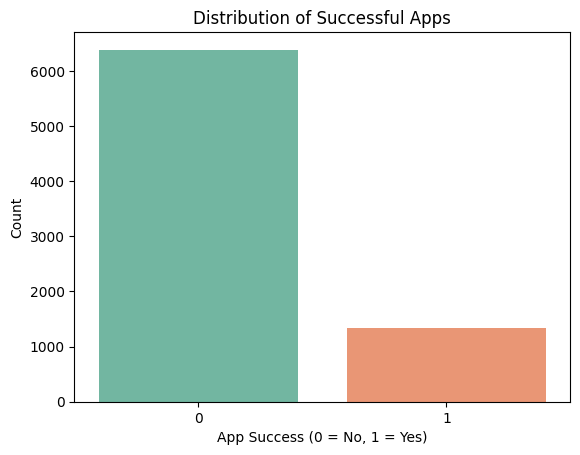

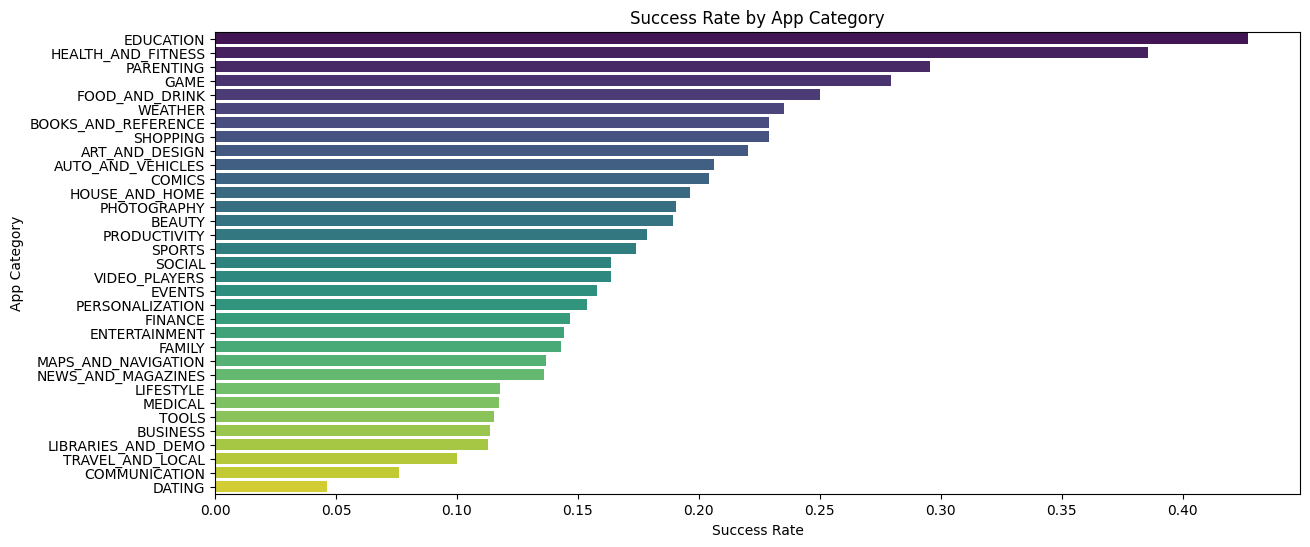

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution of success
sns.countplot(data=df, x='Success', hue='Success', palette='Set2', legend=False)
plt.title("Distribution of Successful Apps")
plt.xlabel("App Success (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# 2. Success Rate by Category
plt.figure(figsize=(14,6))
success_rate = df.groupby('Category')['Success'].mean().sort_values(ascending=False)
sns.barplot(y=success_rate.index, x=success_rate.values, hue=success_rate.index, palette='viridis', legend=False)
plt.title("Success Rate by App Category")
plt.xlabel("Success Rate")
plt.ylabel("App Category")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Features
features = ['Reviews', 'Size', 'Installs', 'Category', 'Content Rating']

# One-hot encode categorical features
df_encoded = pd.get_dummies(df[features], drop_first=True)

# Define target
X = df_encoded
y = df['Success']

# Split into train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print("Model Evaluation:\n")
print(confusion_matrix(y_test, y_pred))
print("\n" + classification_report(y_test, y_pred))

Model Evaluation:

[[1225   53]
 [ 141  127]]

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1278
           1       0.71      0.47      0.57       268

    accuracy                           0.87      1546
   macro avg       0.80      0.72      0.75      1546
weighted avg       0.86      0.87      0.86      1546



/var/folders/pz/qq_g0z9j55vd4plml29lz6n40000gn/T/ipykernel_31805/1535289658.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:15], y=feature_names[indices][:15], palette='coolwarm')


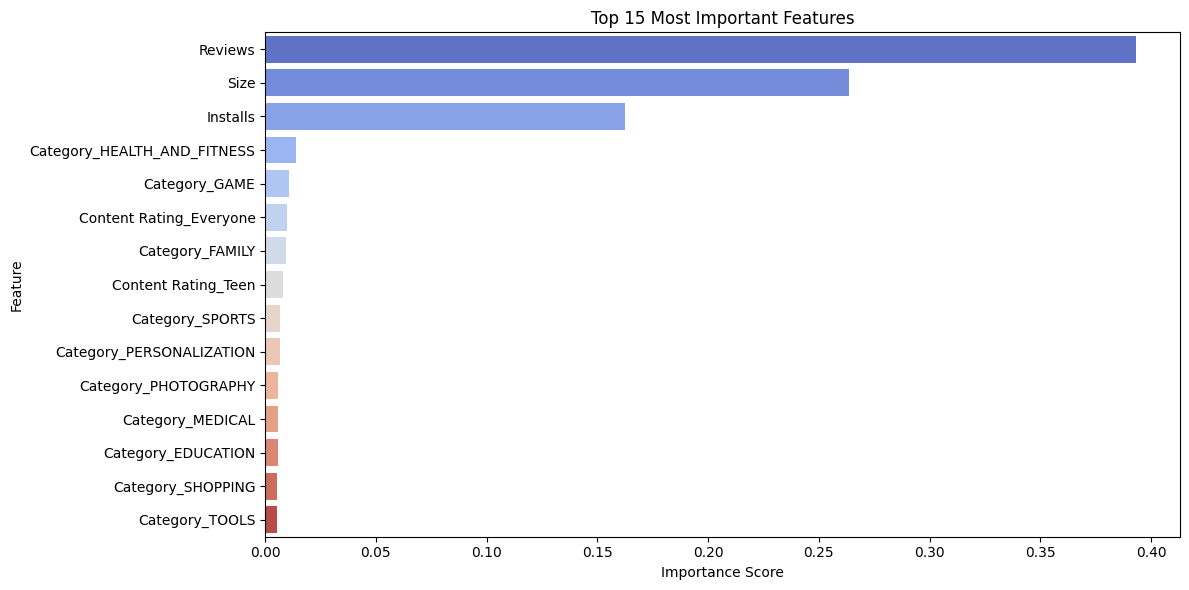

In [10]:
# Feature Importance Plot
import numpy as np

importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
sns.barplot(x=importances[indices][:15], y=feature_names[indices][:15], palette='coolwarm')
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()